In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\eshwa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df = pd.read_csv(
    "train (1).csv",
    encoding='latin1',
    engine='python',
    on_bad_lines='skip'
)

In [5]:
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
162043,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
162044,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
162045,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
162046,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [6]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162048 entries, 0 to 162047
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             162047 non-null  object
 1   comment_text   158525 non-null  object
 2   toxic          158182 non-null  object
 3   severe_toxic   157989 non-null  object
 4   obscene        157888 non-null  object
 5   threat         157807 non-null  object
 6   insult         157772 non-null  object
 7   identity_hate  157406 non-null  object
dtypes: object(8)
memory usage: 9.9+ MB


In [11]:
df.shape

(162048, 8)

In [8]:
df.isnull().sum()

id                  1
comment_text     3523
toxic            3866
severe_toxic     4059
obscene          4160
threat           4241
insult           4276
identity_hate    4642
dtype: int64

In [12]:
df['comment_text'] = df['comment_text'].fillna('')

In [15]:
target_cols = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

df[target_cols] = df[target_cols].fillna(0)
df['id'] = df['id'].fillna(-1)

In [16]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [22]:
df.dtypes

id               object
comment_text     object
toxic            object
severe_toxic     object
obscene          object
threat           object
insult           object
identity_hate    object
dtype: object

In [29]:
for col in labels:
    df[col]=pd.to_numeric(df[col],errors='coerce')
    df[labels]=df[labels].fillna(0)

In [30]:
# text cleaning
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [45]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    words = text.split()

    clean_words = []

    for word in words:

        if len(word) > 30:
            continue

        if word not in stop_words:

            try:
                clean_words.append(
                    stemmer.stem(word)
                )

            except:
                pass

    return " ".join(clean_words)

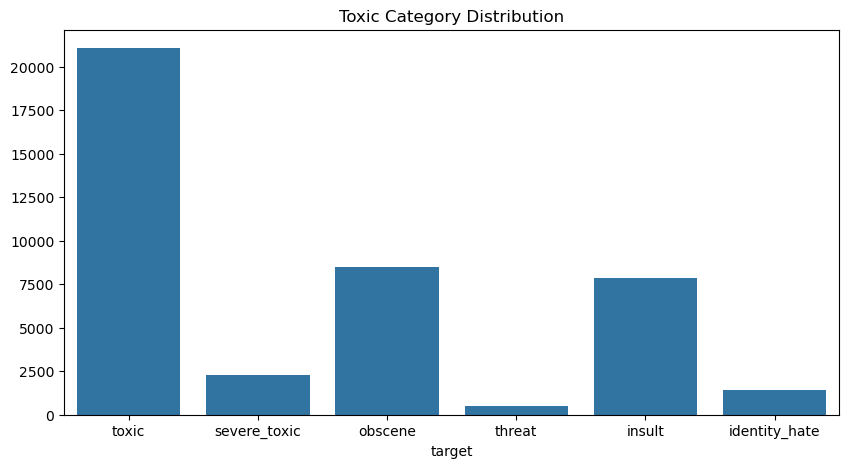

In [37]:
# EDA
# barplot
labels = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

counts = df[labels].sum()

plt.figure(figsize=(10,5))

sns.barplot(
    x=counts.index,
    y=counts.values
)

plt.xlabel("target")
plt.title("Toxic Category Distribution")

plt.show()

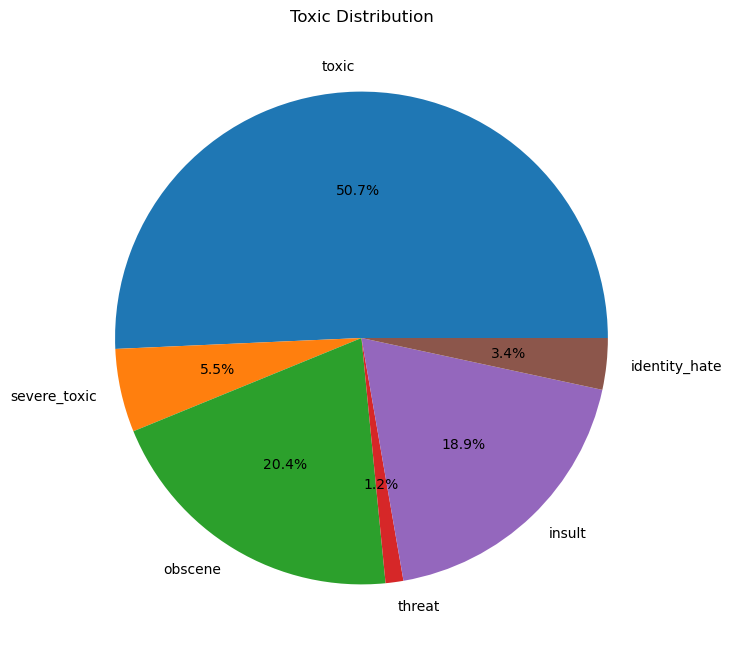

In [38]:
# pie chart
counts.plot.pie(autopct='%1.1f%%',figsize=(8,8))
plt.title("Toxic Distribution")
plt.show()

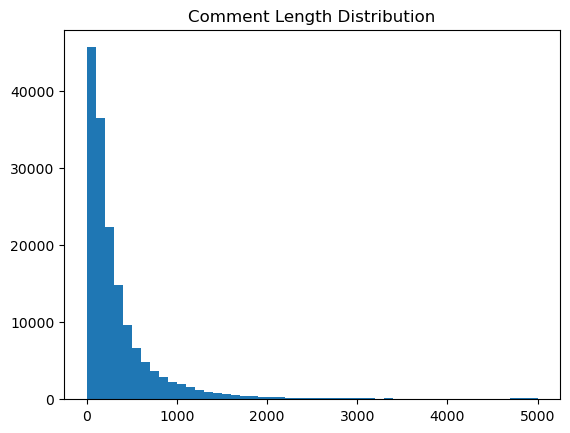

In [39]:
# histogram
df['comment_length'] = df['comment_text'].apply(len)
plt.hist(df['comment_length'],bins=50)
plt.title("Comment Length Distribution")
plt.show()

In [47]:
# feature extraction
tfidf = TfidfVectorizer(max_features=10000)

In [48]:
# fit transform
df['clean_comment'] = df['comment_text'].apply(clean_text)
X = tfidf.fit_transform(df['clean_comment'])

In [49]:
#target variables
y = df[
    [
        'toxic',
        'severe_toxic',
        'obscene',
        'threat',
        'insult',
        'identity_hate'
    ]
]

In [52]:
# train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
# model building
model = MultiOutputClassifier(
    LogisticRegression(max_iter=200)
)

In [58]:
# model training
model.fit(
    X_train,
    y_train
)

,estimator,LogisticRegre...(max_iter=200)
,n_jobs,None
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'


In [61]:
y_pred = model.predict(
    X_test
)

In [63]:
print(y_test.shape)
print(y_pred.shape)

(32410, 6)
(32410, 6)


In [64]:
y_pred_df = pd.DataFrame(
    y_pred,
    columns=y_test.columns
)

In [67]:
for col in y_test.columns:

    print("\n")
    print("="*50)
    print("Category:", col)
    print("="*50)

    print(
        classification_report(
            y_test[col],
            y_pred_df[col]
        )
    )



Category: toxic
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98     29358
         1.0       0.89      0.65      0.75      3051
      1842.0       0.00      0.00      0.00         1

    accuracy                           0.96     32410
   macro avg       0.62      0.55      0.58     32410
weighted avg       0.96      0.96      0.96     32410



Category: severe_toxic
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     32107
         1.0       0.45      0.24      0.31       303

    accuracy                           0.99     32410
   macro avg       0.72      0.62      0.65     32410
weighted avg       0.99      0.99      0.99     32410



Category: obscene
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     30720
         1.0       0.89      0.69      0.78      1690

    accuracy                           0.98     32410
   macro av

In [68]:
sample = [
    "you are stupid idiot"
]

In [69]:
sample_clean = [
    clean_text(text)
    for text in sample
]

In [70]:
sample_vector = tfidf.transform(
    sample_clean
)

In [71]:
prediction = model.predict(
    sample_vector
)

In [72]:
print(prediction)

[[1. 0. 1. 0. 1. 0.]]


In [73]:
import pickle

pickle.dump(
    model,
    open("toxic_model.pkl","wb")
)

pickle.dump(
    tfidf,
    open("tfidf.pkl","wb")
)